# 05 · How do hotels actually reprice?  (Parts 2 & 7)

**Caveat:** `average_rate` is a category *mean*, not a posted price, so it
moves almost every month — a menu-cost "frequency of repricing" is essentially
**not observable** in this data (freq ≈ 1 by construction). The informative
margins are the **size**, **sign / upward asymmetry**, and **CPI pass-through**
of the monthly change, and how those shift with inflation.

**Key hypothesis (test, don't assume):**
*"High inflation makes hotels reprice MORE FREQUENTLY."*
vs the alternative the earlier analysis hinted at:
*"High inflation makes each repricing LARGER, more UPWARD, and raises
pass-through, without raising an already-saturated frequency."*

Sample: main analysis sample (2018-19 + 2022 … 2026-05), COVID held out.

**Output** `outputs/tables/table2_regime_behaviour.csv`,
`table3_passthrough.csv`, `regime_tests.csv`,
`outputs/figures/05_chart3_*.png`, `05_chart4_*.png`, `05_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("05_repricing")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

df = pd.read_parquet(C.P_ANALYSIS)
df = df[(df.in_sample == 1)].copy()
df["dln_cpi_gba"] = np.log1p(df["infl_mom_gba"] / 100)
df["dln_cpi_nac"] = np.log1p(df["infl_mom_nac"] / 100)
CORE = C.CORE_CATEGORIES
ALLc = C.MODEL_CATEGORIES
LAB = C.CATEGORY_LABELS
HAC = dict(cov_type="HAC", cov_kwds={"maxlags": 6})

# data-driven inflation regimes: terciles of GBA MoM inflation within the sample
edges = df["infl_mom_gba"].quantile(C.REGIME_QUANTILES).values
df["regime"] = pd.cut(df["infl_mom_gba"], edges, include_lowest=True,
                      labels=C.REGIME_LABELS)
LOG.log("regimes", "GBA MoM inflation terciles",
        detail=f"cuts {edges[1]:.2f}% / {edges[2]:.2f}%  (max {edges[3]:.1f}%)")

  [05_repricing] regimes                GBA MoM inflation terciles                 cuts 2.82% / 5.34%  (max 25.1%)


## 1 · Repricing behaviour by category  (Part 2)

In [2]:
rows = []
for cat, s in df[df.hotel_category.isin(ALLc)].groupby("hotel_category"):
    d = s["dln_average_rate"].dropna()
    pos, neg = d[d > 0], d[d < 0]
    dcpi = s.loc[d.index, "dln_cpi_gba"]
    rows.append(dict(
        hotel_category=cat, label=LAB[cat], n=len(d),
        freq_change_gt_0p1pct=(d.abs() > 1e-3).mean(),
        freq_change_gt_1pct=(d.abs() > 1e-2).mean(),
        share_up=(d > 0).mean(),
        mean_abs_change_pct=d.abs().mean() * 100,
        median_abs_change_pct=d.abs().median() * 100,
        mean_pos_change_pct=pos.mean() * 100, mean_neg_change_pct=neg.mean() * 100,
        p90_change_pct=d.quantile(.9) * 100, p10_change_pct=d.quantile(.1) * 100,
        share_change_gt_cpi=(d > dcpi).mean(),
        share_change_lt_cpi=(d < dcpi).mean(),
    ))
padj = pd.DataFrame(rows).set_index("hotel_category").round(3)
padj.to_csv(C.OUT_TAB / "price_adjustment_by_category.csv")
LOG.log("write", "price_adjustment_by_category.csv", len(padj))
padj

  [05_repricing] write                  price_adjustment_by_category.csv        6  


,label,n,freq_change_gt_0p1pct,freq_change_gt_1pct,share_up,mean_abs_change_pct,median_abs_change_pct,mean_pos_change_pct,mean_neg_change_pct,p90_change_pct,p10_change_pct,share_change_gt_cpi,share_change_lt_cpi
hotel_category,,,,,,,,,,,,,
apart,Apart-hotel,73,0.973,0.877,0.822,9.146,6.757,8.733,-11.051,15.841,-5.206,0.493,0.493
boutique,Boutique,73,1.000,0.959,0.767,7.549,6.032,8.505,-4.399,15.136,-3.792,0.589,0.397
stars_1_2,1-2 star,61,0.984,0.934,0.803,6.712,5.014,6.963,-5.688,11.706,-2.203,0.475,0.508
stars_3,3 star,73,0.986,0.904,0.740,8.136,6.071,9.426,-4.471,18.957,-3.188,0.493,0.493
stars_4,4 star,73,1.000,0.904,0.795,7.584,6.023,8.567,-3.781,15.879,-2.874,0.534,0.452
stars_5,5 star,73,1.000,0.945,0.644,10.563,7.867,12.350,-7.332,17.236,-9.171,0.466,0.521


## 2 · Inflation pass-through by category  (Table 3)

Δln P_t = α + β Δln CPI_t + ε  (contemporaneous, HAC SE).
Distributed-lag 0–2: cumulative pass-through = Σ β_k (short, to avoid overfit).

In [3]:
def fit(s, lags):
    s = s.dropna(subset=["dln_average_rate", "dln_cpi_gba"]).sort_values("date")
    X = pd.DataFrame({"l0": s["dln_cpi_gba"]}, index=s.index)
    for k in range(1, lags + 1):
        X[f"l{k}"] = s["dln_cpi_gba"].shift(k)
    XY = pd.concat([s["dln_average_rate"].rename("y"), X], axis=1).dropna()
    if len(XY) < 20:
        return None
    return sm.OLS(XY["y"], sm.add_constant(XY[X.columns])).fit(**HAC)


rows = []
for cat, s in df[df.hotel_category.isin(ALLc)].groupby("hotel_category"):
    m0, m2 = fit(s, 0), fit(s, 2)
    if m0 is None:
        continue
    lags = [c for c in m2.params.index if c.startswith("l")] if m2 is not None else []
    cum = float(m2.params[lags].sum()) if m2 is not None else np.nan
    rows.append(dict(hotel_category=cat, label=LAB[cat], n=int(m0.nobs),
                     beta_contemp=round(m0.params["l0"], 3),
                     se=round(m0.bse["l0"], 3), t=round(m0.tvalues["l0"], 2),
                     r2=round(m0.rsquared, 3),
                     beta_cum_0_2=round(cum, 3) if m2 is not None else np.nan))
tab3 = pd.DataFrame(rows).set_index("hotel_category")
tab3.to_csv(C.OUT_TAB / "table3_passthrough.csv")
LOG.log("write", "table3_passthrough.csv", len(tab3))
tab3

  [05_repricing] write                  table3_passthrough.csv                  6  


,label,n,beta_contemp,se,t,r2,beta_cum_0_2
hotel_category,,,,,,,
apart,Apart-hotel,72,1.051,0.266,3.95,0.108,0.908
boutique,Boutique,72,1.200,0.188,6.39,0.298,0.922
stars_1_2,1-2 star,60,0.879,0.119,7.36,0.190,0.790
stars_3,3 star,72,0.825,0.189,4.37,0.130,0.660
stars_4,4 star,72,1.077,0.168,6.40,0.280,0.784
stars_5,5 star,72,1.227,0.290,4.23,0.103,0.921


## 3 · Behaviour by inflation regime  (Table 2, Part 7)

Pooled over the four star tiers. Frequency, magnitude, upward share,
pass-through, occupancy, real price by regime.

In [4]:
pool = df[df.hotel_category.isin(CORE)].dropna(
    subset=["dln_average_rate", "dln_cpi_gba", "real_rate_gba", "room_occupancy", "regime"]).copy()
tab2 = (pool.groupby("regime", observed=True)
        .agg(n=("dln_average_rate", "size"),
             cpi_mom_mean_pct=("infl_mom_gba", "mean"),
             freq_change_gt_1pct=("dln_average_rate", lambda x: (x.abs() > .01).mean()),
             mean_abs_change_pct=("dln_average_rate", lambda x: x.abs().mean() * 100),
             median_abs_change_pct=("dln_average_rate", lambda x: x.abs().median() * 100),
             share_up=("dln_average_rate", lambda x: (x > 0).mean()),
             mean_real_rate=("real_rate_gba", "mean"),
             mean_room_occ=("room_occupancy", "mean")).round(3))
# regime pass-through: separate OLS per regime (no fragile interaction terms)
pt = {}
for r in C.REGIME_LABELS:
    g = pool[pool.regime == r]
    m = sm.OLS(g["dln_average_rate"], sm.add_constant(g["dln_cpi_gba"])).fit(**HAC)
    pt[r] = (round(m.params["dln_cpi_gba"], 3), round(m.tvalues["dln_cpi_gba"], 2), int(m.nobs))
tab2["passthrough_beta"] = [pt[r][0] for r in tab2.index]
tab2["passthrough_t"] = [pt[r][1] for r in tab2.index]
tab2.to_csv(C.OUT_TAB / "table2_regime_behaviour.csv")
LOG.log("write", "table2_regime_behaviour.csv", len(tab2))
tab2

  [05_repricing] write                  table2_regime_behaviour.csv             3  


,n,cpi_mom_mean_pct,freq_change_gt_1pct,mean_abs_change_pct,median_abs_change_pct,share_up,mean_real_rate,mean_room_occ,passthrough_beta,passthrough_t
regime,,,,,,,,,,
low,92,2.314,0.880,7.359,5.565,0.652,1318.356,57.724,0.477,0.25
mid,92,3.941,0.902,6.217,4.513,0.707,1526.623,59.145,2.818,3.06
high,92,9.573,0.978,11.261,10.320,0.870,1610.877,63.825,0.663,3.90


## 4 · Formal tests of the key hypothesis

Pooled OLS over the four star tiers, category fixed effects, HAC(6) SE:

* **Magnitude:**  |Δln P|_t  = a + b·1[mid] + c·1[high] + FE
* **Asymmetry:**  1[ΔP>0]_t  = a + b·1[mid] + c·1[high] + FE  (LPM)
* **Frequency:**  1[|Δln P|>1%]_t = a + b·1[mid] + c·1[high] + FE  (LPM)
* **Pass-through:** Δln P_t = … + β0·Δln CPI + β1·(Δln CPI·1[mid]) + β2·(…·1[high])

"High inflation → repriced more often" ⇒ significant positive `c` in the
frequency model. "More consequential, not more frequent" ⇒ significant `c` in
magnitude / asymmetry / pass-through but not in frequency.

In [5]:
pool = pool.assign(absdln=pool["dln_average_rate"].abs() * 100,
                   up=(pool["dln_average_rate"] > 0).astype(float),
                   big=(pool["dln_average_rate"].abs() > .01).astype(float),
                   mid=(pool["regime"] == "mid").astype(float),
                   high=(pool["regime"] == "high").astype(float),
                   catf=pool["hotel_category"].astype("category"))
tests = []
for name, formula in [
    ("magnitude |dlnP| (pp)", "absdln ~ mid + high + catf"),
    ("asymmetry P(up) (LPM)", "up ~ mid + high + catf"),
    ("frequency P(|dlnP|>1%) (LPM)", "big ~ mid + high + catf"),
    ("pass-through (interacted)",
     "dln_average_rate ~ dln_cpi_gba + dln_cpi_gba:mid + dln_cpi_gba:high + catf"),
]:
    m = smf.ols(formula, data=pool).fit(**HAC)
    for term in ["mid", "high", "dln_cpi_gba:mid", "dln_cpi_gba:high"]:
        if term in m.params.index:
            tests.append(dict(model=name, term=term,
                              coef=round(m.params[term], 4),
                              t=round(m.tvalues[term], 2),
                              p=round(m.pvalues[term], 4)))
regime_tests = pd.DataFrame(tests)
regime_tests.to_csv(C.OUT_TAB / "regime_tests.csv", index=False)
LOG.log("write", "regime_tests.csv", len(regime_tests))
regime_tests

  [05_repricing] write                  regime_tests.csv                        8  


,model,term,coef,t,p
0,magnitude |dlnP| (pp),mid,-1.1968,-1.28,0.2000
1,magnitude |dlnP| (pp),high,3.7924,3.25,0.0012
2,asymmetry P(up) (LPM),mid,0.0572,1.04,0.3000
3,asymmetry P(up) (LPM),high,0.2231,4.42,0.0000
4,frequency P(|dlnP|>1%) (LPM),mid,0.0225,0.48,0.6303
5,frequency P(|dlnP|>1%) (LPM),high,0.0993,2.58,0.0099
6,pass-through (interacted),dln_cpi_gba:mid,0.5071,1.09,0.2768
7,pass-through (interacted),dln_cpi_gba:high,0.9275,1.69,0.0920


## Chart 3 — "High inflation changed the SIZE of price adjustments"

  [05_repricing] figure                 05_chart3_magnitude_by_regime.png           


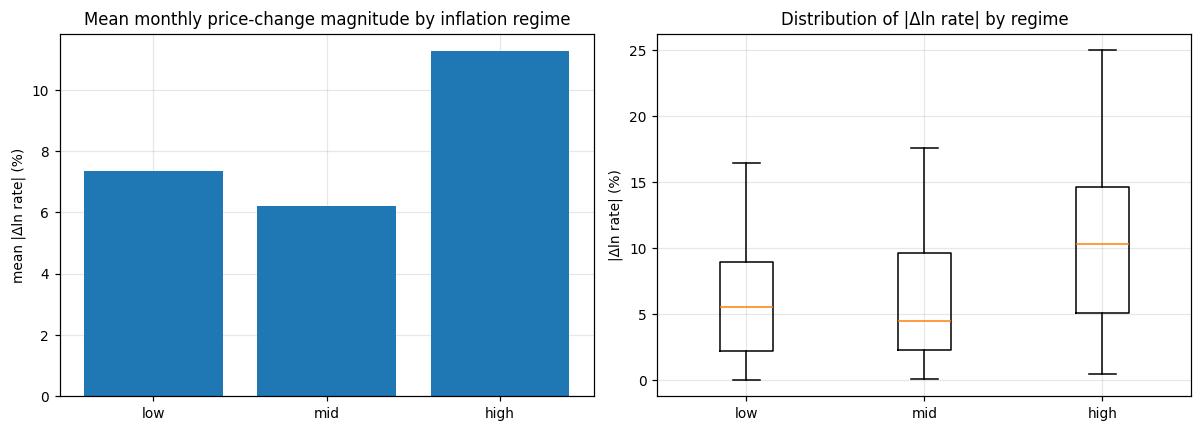

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
order = C.REGIME_LABELS
ax[0].bar(order, [tab2.loc[r, "mean_abs_change_pct"] for r in order], color="tab:blue")
ax[0].set_ylabel("mean |Δln rate| (%)")
ax[0].set_title("Mean monthly price-change magnitude by inflation regime")
box = [pool.loc[pool.regime == r, "absdln"] for r in order]
ax[1].boxplot(box, tick_labels=order, showfliers=False)
ax[1].set_ylabel("|Δln rate| (%)"); ax[1].set_title("Distribution of |Δln rate| by regime")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "05_chart3_magnitude_by_regime.png")
LOG.log("figure", "05_chart3_magnitude_by_regime.png"); plt.show()

## Chart 4 — "Hotels don't simply reprice more often"

  [05_repricing] figure                 05_chart4_frequency_by_regime.png           


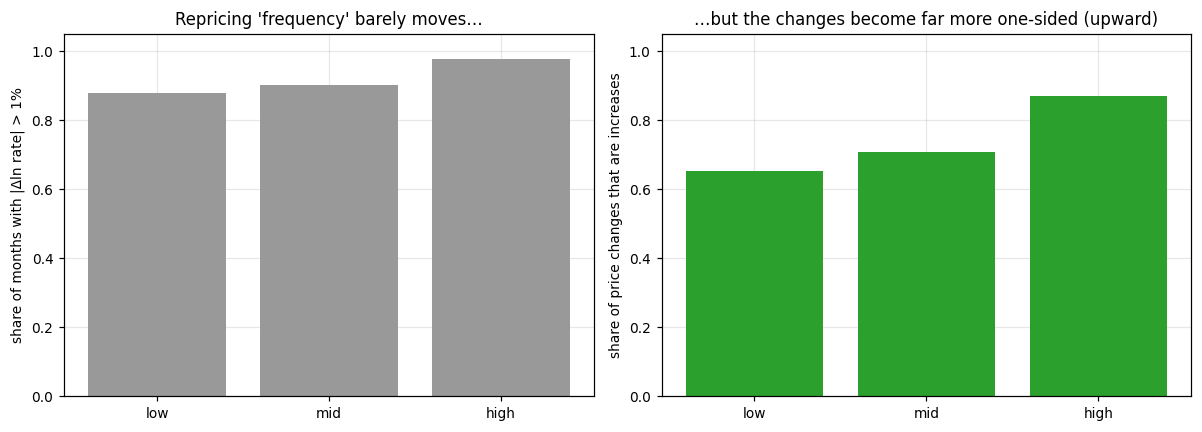

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(order, [tab2.loc[r, "freq_change_gt_1pct"] for r in order], color="0.6")
ax[0].set_ylim(0, 1.05); ax[0].set_ylabel("share of months with |Δln rate| > 1%")
ax[0].set_title("Repricing 'frequency' barely moves…")
ax[1].bar(order, [tab2.loc[r, "share_up"] for r in order], color="tab:green")
ax[1].set_ylim(0, 1.05); ax[1].set_ylabel("share of price changes that are increases")
ax[1].set_title("…but the changes become far more one-sided (upward)")
fig.tight_layout(); fig.savefig(C.OUT_FIG / "05_chart4_frequency_by_regime.png")
LOG.log("figure", "05_chart4_frequency_by_regime.png"); plt.show()

## Chart B — cumulative rate vs cumulative CPI (real erosion between catch-ups)

  [05_repricing] figure                 05_cumulative_passthrough.png              


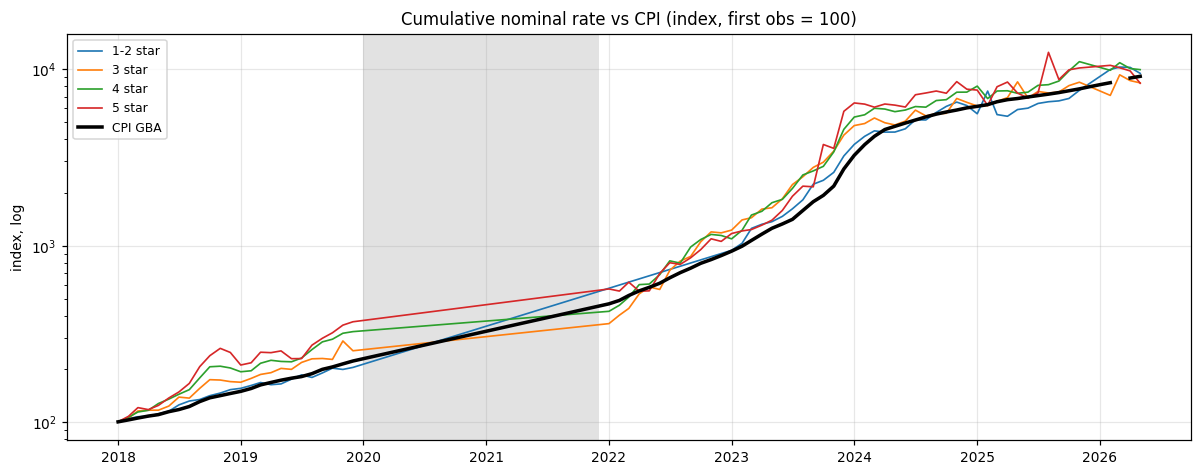

In [8]:
piv = df.pivot_table(index="date", columns="hotel_category", values="average_rate")
cpi_lvl = df.groupby("date")["cpi_gba"].first()
fig, ax = plt.subplots(figsize=(11, 4.4))
b0 = piv.dropna(how="all").index.min()
for cat in CORE:
    s = piv[cat].dropna()
    ax.plot(s.index, s / s.iloc[0] * 100, lw=1.1, label=LAB[cat])
ax.plot(cpi_lvl.index, cpi_lvl / cpi_lvl.loc[b0] * 100, lw=2.3, color="k", label="CPI GBA")
ax.axvspan(pd.Timestamp(C.COVID_START), pd.Timestamp(C.COVID_END), color="0.6", alpha=.28, lw=0)
ax.set_yscale("log")
ax.set_title("Cumulative nominal rate vs CPI (index, first obs = 100)")
ax.set_ylabel("index, log"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "05_cumulative_passthrough.png")
LOG.log("figure", "05_cumulative_passthrough.png"); plt.show()

## Verdict

In [9]:
freq_high = regime_tests.query("model.str.startswith('frequency') and term=='high'").iloc[0]
mag_high = regime_tests.query("model.str.startswith('magnitude') and term=='high'").iloc[0]
asym_high = regime_tests.query("model.str.startswith('asymmetry') and term=='high'").iloc[0]
pt_high = regime_tests.query("term=='dln_cpi_gba:high'").iloc[0]
print("HIGH-inflation regime vs LOW (pooled, category FE, HAC):")
print(f"  frequency  (|ΔP|>1%): coef {freq_high.coef:+.3f}  p={freq_high.p}")
print(f"  magnitude  (|ΔlnP| pp): coef {mag_high.coef:+.3f}  p={mag_high.p}")
print(f"  asymmetry  (P(up)):   coef {asym_high.coef:+.3f}  p={asym_high.p}")
print(f"  pass-through slope:   coef {pt_high.coef:+.3f}  p={pt_high.p}")
base_freq = tab2.loc["low", "freq_change_gt_1pct"]
consequential = (mag_high.p < 0.05) and (asym_high.p < 0.05)
freq_material = (freq_high.p < 0.05) and (freq_high.coef > 0.15)   # >15pp jump = "material"
if consequential and not freq_material:
    verdict = (f"SUPPORTED. High inflation makes each repricing much LARGER "
               f"(+{mag_high.coef:.1f}pp, p={mag_high.p}) and far more UPWARD "
               f"(+{asym_high.coef:.2f}, p={asym_high.p}). The >1% frequency does rise "
               f"(+{freq_high.coef:.2f}, p={freq_high.p}) but only ~{freq_high.coef*100:.0f}pp "
               f"from an already-high {base_freq:.0%} base -- the magnitude/asymmetry "
               f"response dominates. 'Inflation does not mainly make hotels reprice more "
               f"often; it makes each repricing more consequential.'")
else:
    verdict = "MIXED -- see regime_tests.csv"
LOG.log("key_hypothesis", "verdict", detail=verdict[:180])
print("\n=>", verdict)
LOG.flush()

HIGH-inflation regime vs LOW (pooled, category FE, HAC):
  frequency  (|ΔP|>1%): coef +0.099  p=0.0099
  magnitude  (|ΔlnP| pp): coef +3.792  p=0.0012
  asymmetry  (P(up)):   coef +0.223  p=0.0
  pass-through slope:   coef +0.927  p=0.092
  [05_repricing] key_hypothesis         verdict                                    SUPPORTED. High inflation makes each repricing much LARGER (+3.8pp, p=0.0012) and far more UPWARD (+0.22, p=0.0). The >1% frequency does rise (+0.10, p=0.0099) but only ~10pp from 

=> SUPPORTED. High inflation makes each repricing much LARGER (+3.8pp, p=0.0012) and far more UPWARD (+0.22, p=0.0). The >1% frequency does rise (+0.10, p=0.0099) but only ~10pp from an already-high 88% base -- the magnitude/asymmetry response dominates. 'Inflation does not mainly make hotels reprice more often; it makes each repricing more consequential.'
